#  DocForge Exploratory Data Analysis

**Your job:** Fill in every `# TODO` cell below. Each cell tells you exactly what to do.

Do NOT skip cells — each one builds on the last.

---
### What is the dataset?
You are working with **Code2Doc** — a curated dataset of real function-documentation pairs scraped from popular open-source repositories (Spring, Pandas, TypeScript compiler, etc.).

Each row is one function paired with its docstring. Your goal in this notebook is to **understand the data** before you clean or train anything.

---
### Sections
1. Install & Import
2. Load the Dataset
3. Basic Overview
4. Language Distribution
5. Quality Score Analysis
6. Code Length Analysis
7. Docstring Length Analysis
8. Token Count Estimation
9. Cyclomatic Complexity
10. Per-Language Summary
11. Sample Inspection
12. Key Insights

---
## Section 1 — Install & Import

Run this cell as-is. It installs and imports everything you need.

In [1]:
!pip install datasets -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11


---
## Section 2 — Load the Dataset

**Task:** Load the Code2Doc dataset from HuggingFace and convert the training split to a pandas DataFrame.

The dataset is hosted at: `kaanrkaraman/code2doc`

**Hint:** Use `load_dataset(...)` then `.to_pandas()` on the split you want..

In [2]:
dataset = load_dataset("kaanrkaraman/code2doc")
print(dataset)

df = dataset["train"].to_pandas()
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/6.51M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/860k [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/857k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10684 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1340 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/1334 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 10684
    })
    test: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 1340
    })
    val: Dataset({
        features: ['function_name', 'function_code', 'documentation', 'language', 'file_path', 'line_number', 'parameters', 'return_type', 'has_type_hints', 'complexity', 'quality_score', 'repo_name', 'repo_stars', 'docstring_style', 'is_async'],
        num_rows: 1334
    })
})
Rows: 10684, Columns: 15


---
## Section 2b — Fix Array-Type Columns

Some columns (like `parameters`) store Python lists instead of plain strings.
This breaks `.unique()` and `.value_counts()` later on.

**Task:** Write a loop that checks each column, detects if its values are lists/arrays, and converts them to comma-separated strings.

**Hint:** Use `isinstance(value, (list, np.ndarray))` to check. Use `', '.join(...)` to convert.

In [3]:
for col in df.columns:
    first_val = df[col].dropna().iloc[0] if not df[col].dropna().empty else None
    if isinstance(first_val, (list, np.ndarray)):
        print(f"Converting column: {col}")
        df[col] = df[col].apply(lambda x: ", ".join(map(str, x)) if isinstance(x, (list, np.ndarray)) else x)

print(df.dtypes)

Converting column: parameters
function_name       object
function_code       object
documentation       object
language            object
file_path           object
line_number          int32
parameters          object
return_type         object
has_type_hints        bool
complexity           int32
quality_score      float32
repo_name           object
repo_stars           int32
docstring_style     object
is_async              bool
dtype: object


---
## Section 3 — Basic Overview

**Task:** Explore the structure of the DataFrame — what columns exist, what types they are, and whether any have missing values.

**Hint:** Use `.head()`, `.dtypes`, `.isnull().sum()`, and `.nunique()`.

In [4]:
print(df.head(3))

print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "unique": df.nunique()
})
print("\nColumn Summary:")
print(summary)

print("\nFirst row values:")
for col in df.columns:
    val = str(df[col].iloc[0])
    print(f"  {col}: {val[:120]}")

        function_name                                      function_code  \
0  parseTypeParameter  function parseTypeParameter(): TypeParameterDe...   
1             convert  def convert(self, values: np.ndarray, nan_rep,...   
2              equals  @Override\n\t\tpublic boolean equals(Object ob...   

                                       documentation    language  \
0  Reports a diagnostic error for the current tok...  typescript   
1  Convert the data from this selection to the ap...      python   
2  Return the column of the text resource where t...        java   

                                           file_path  line_number  \
0                             src/compiler/parser.ts         3955   
1                              pandas/io/pytables.py         2655   
2  core/spring-boot/src/main/java/org/springframe...          166   

                                parameters return_type  has_type_hints  \
0                                                                 True 

---
## Section 4 — Language Distribution

**Task:** Find out how many samples exist per programming language, then visualize it.

**Hint:** The language column is called `language`. Use `.value_counts()` for counts.
Make a bar chart AND a pie chart side by side.

  java: 6560 (61.4%)
  python: 2885 (27.0%)
  typescript: 681 (6.4%)
  javascript: 428 (4.0%)
  cpp: 130 (1.2%)


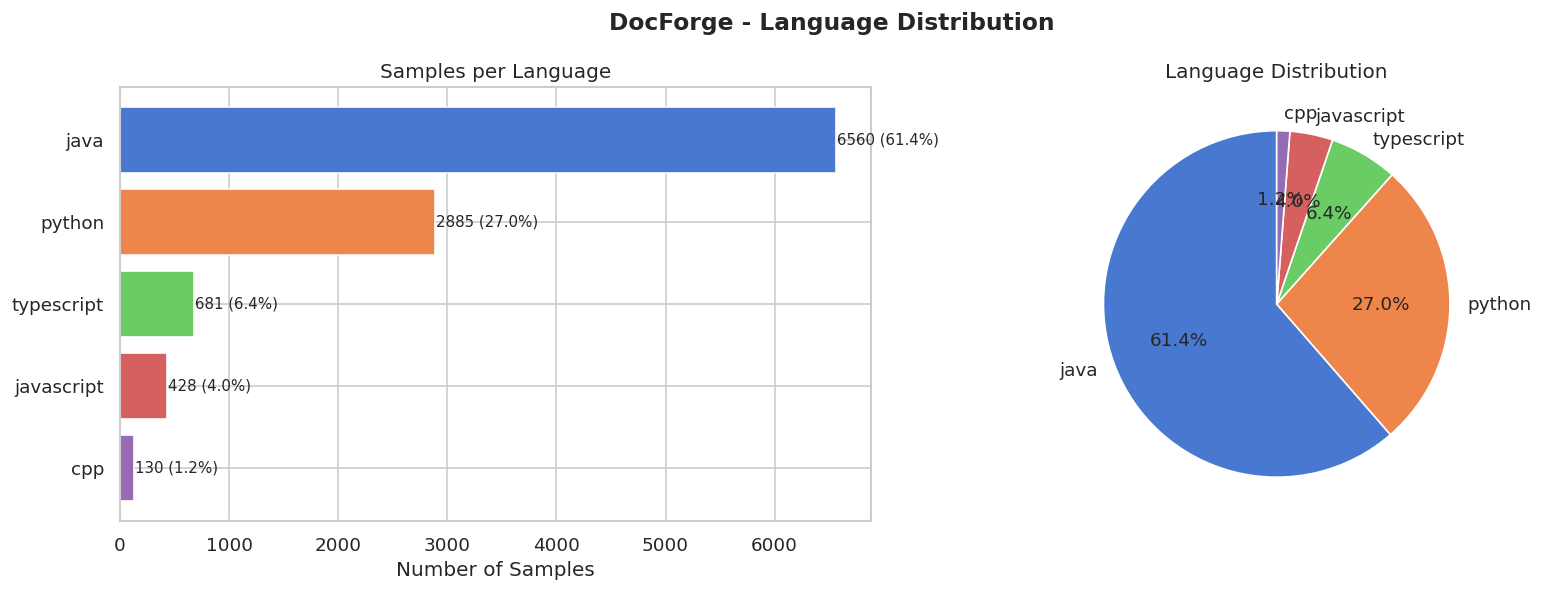


Observation: Java has the most samples, making up the largest share of the dataset.


In [5]:
lang_counts = df["language"].value_counts()
total = len(df)

for lang, count in lang_counts.items():
    print(f"  {lang}: {count} ({count/total*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(lang_counts.index, lang_counts.values, color=sns.color_palette("muted"))
for i, (lang, count) in enumerate(lang_counts.items()):
    ax1.text(count + 10, i, f"{count} ({count/total*100:.1f}%)", va="center", fontsize=9)
ax1.set_xlabel("Number of Samples")
ax1.set_title("Samples per Language")
ax1.invert_yaxis()

ax2.pie(lang_counts.values, labels=lang_counts.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("muted"))
ax2.set_title("Language Distribution")

fig.suptitle("DocForge - Language Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("eda_language_distribution.png", bbox_inches="tight")
plt.show()

print("\nObservation: Java has the most samples, making up the largest share of the dataset.")

---
## Section 5 — Quality Score Analysis

**Task:** Analyze the `quality_score` column — its distribution, key stats, and breakdown by language.

The quality score ranges from 0–10. All samples in this dataset should be ≥ 6.0.

**Hint:** Use `.describe()` for stats. Use `sns.boxplot` for the per-language breakdown.

count    10684.000000
mean         6.924733
std          0.687425
min          6.000000
25%          6.400000
50%          6.800000
75%          7.440000
max          9.680000
Name: quality_score, dtype: float64
Median: 6.800000190734863


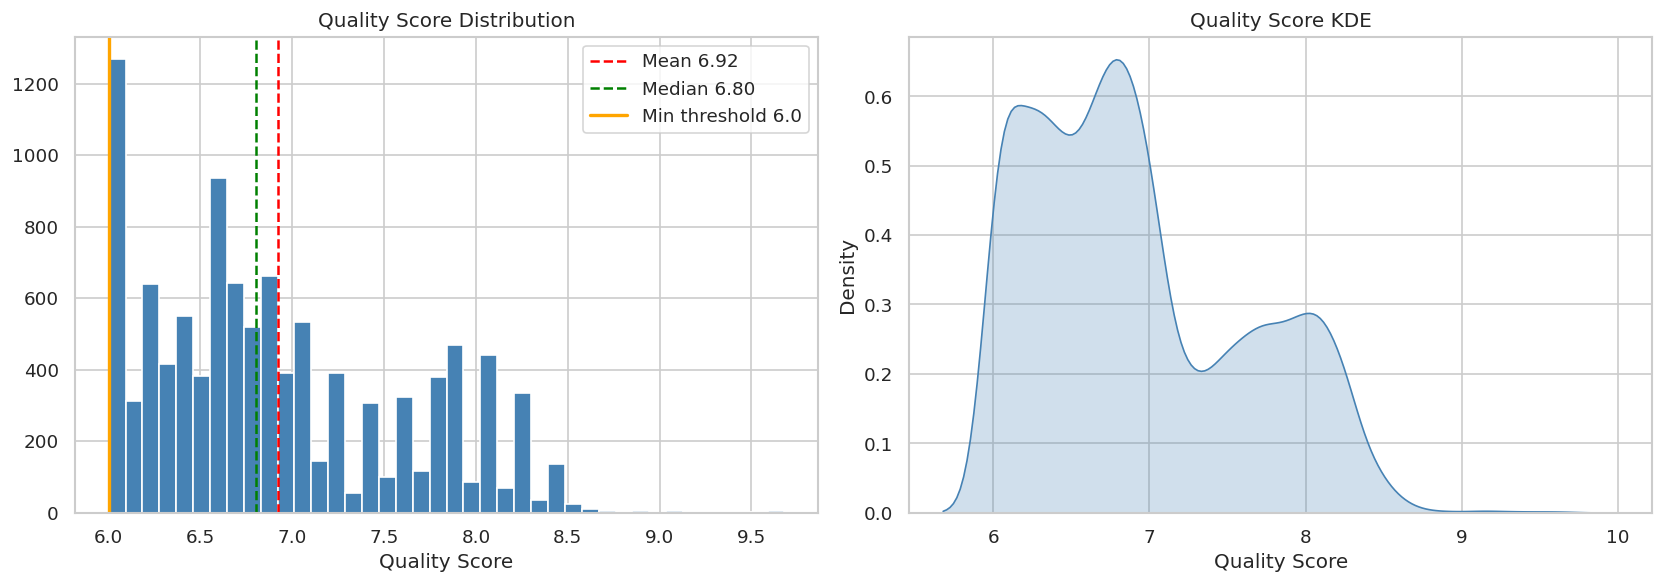

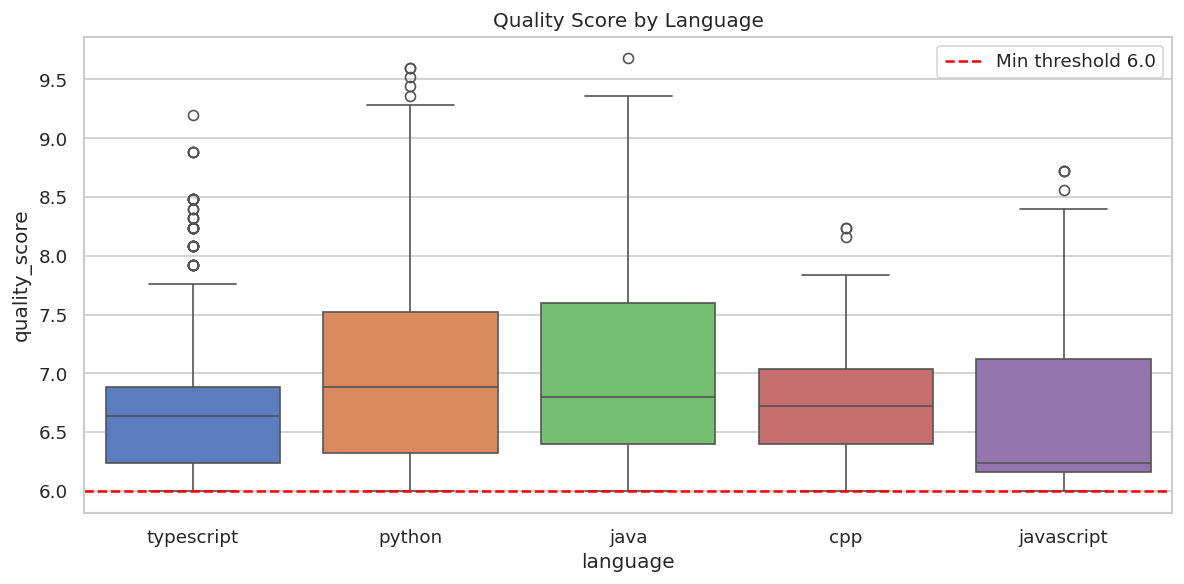


Observation: Most quality scores cluster between 7 and 9, well above the 6.0 minimum threshold.


In [6]:
stats = df["quality_score"].describe()
print(stats)
print(f"Median: {df['quality_score'].median()}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df["quality_score"], bins=40, color="steelblue", edgecolor="white")
ax1.axvline(df["quality_score"].mean(), color="red", linestyle="--", label=f"Mean {df['quality_score'].mean():.2f}")
ax1.axvline(df["quality_score"].median(), color="green", linestyle="--", label=f"Median {df['quality_score'].median():.2f}")
ax1.axvline(6.0, color="orange", linestyle="-", linewidth=2, label="Min threshold 6.0")
ax1.set_title("Quality Score Distribution")
ax1.set_xlabel("Quality Score")
ax1.legend()

sns.kdeplot(df["quality_score"], ax=ax2, fill=True, color="steelblue")
ax2.set_title("Quality Score KDE")
ax2.set_xlabel("Quality Score")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="language", y="quality_score", palette="muted")
plt.axhline(6.0, color="red", linestyle="--", linewidth=1.5, label="Min threshold 6.0")
plt.title("Quality Score by Language")
plt.legend()
plt.tight_layout()
plt.show()

print("\nObservation: Most quality scores cluster between 7 and 9, well above the 6.0 minimum threshold.")

---
## Section 6 — Code Length Analysis

**Task:** Measure how long the functions are — in characters and in lines.

**Hint:** Use `.str.len()` for character count. Use `.str.count('\\n') + 1` for line count.
Cap your histograms at the 99th percentile so outliers don't squash the chart.

       code_char_len  code_line_count
count   10684.000000     10684.000000
mean      771.504586        20.584051
std       825.278555        21.907444
min        20.000000         1.000000
25%       197.000000         5.000000
50%       445.000000        12.000000
75%      1069.000000        29.000000
max      4990.000000       164.000000


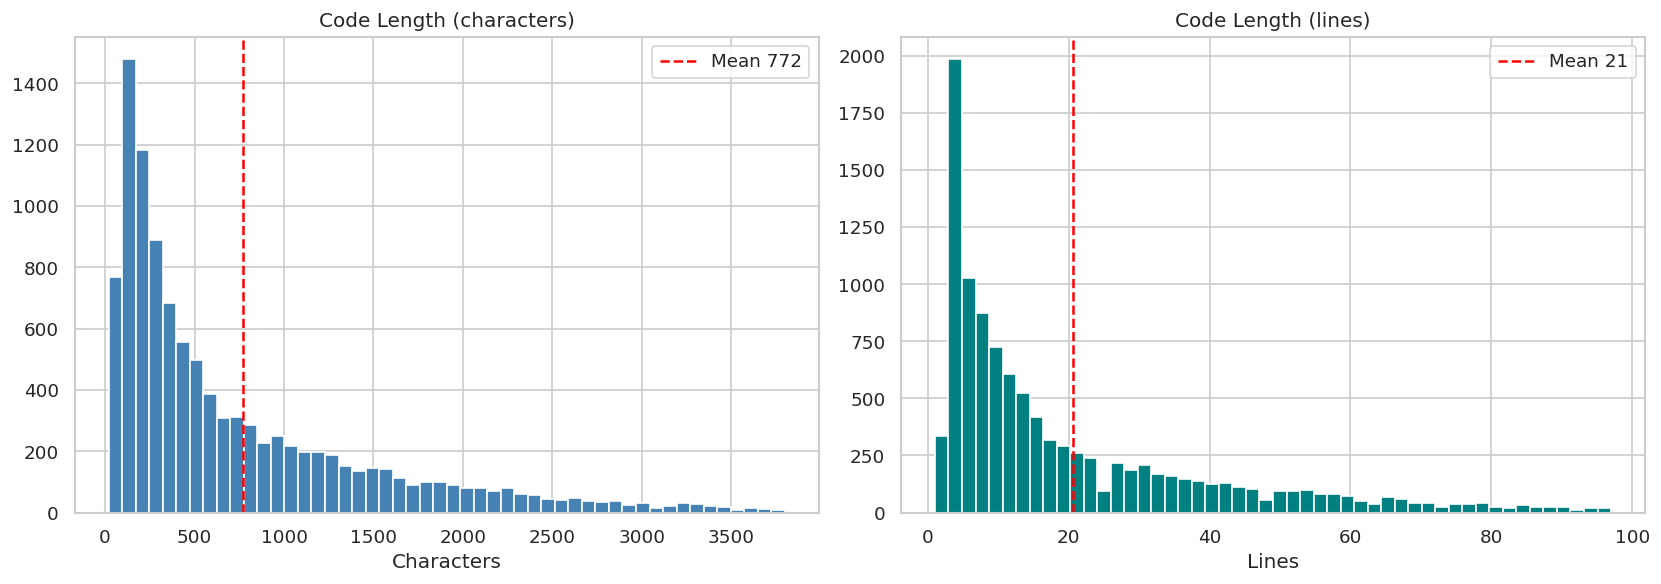


Observation: Most functions are fairly short, around 445 characters and 12 lines on average.


In [7]:
df["code_char_len"] = df["function_code"].str.len()
df["code_line_count"] = df["function_code"].str.count("\n") + 1

print(df[["code_char_len", "code_line_count"]].describe())

cap_chars = df["code_char_len"].quantile(0.99)
cap_lines = df["code_line_count"].quantile(0.99)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df.loc[df["code_char_len"] <= cap_chars, "code_char_len"], bins=50, color="steelblue", edgecolor="white")
ax1.axvline(df["code_char_len"].mean(), color="red", linestyle="--", label=f"Mean {df['code_char_len'].mean():.0f}")
ax1.set_title("Code Length (characters)")
ax1.set_xlabel("Characters")
ax1.legend()

ax2.hist(df.loc[df["code_line_count"] <= cap_lines, "code_line_count"], bins=50, color="teal", edgecolor="white")
ax2.axvline(df["code_line_count"].mean(), color="red", linestyle="--", label=f"Mean {df['code_line_count'].mean():.0f}")
ax2.set_title("Code Length (lines)")
ax2.set_xlabel("Lines")
ax2.legend()

plt.tight_layout()
plt.show()

med_c = df["code_char_len"].median()
med_l = df["code_line_count"].median()
print(f"\nObservation: Most functions are fairly short, around {med_c:.0f} characters and {med_l:.0f} lines on average.")

---
## Section 7 — Docstring Length Analysis

**Task:** Measure how long the docstrings are, then compute the ratio of docstring length to code length.

A ratio > 1 means the docstring is longer than the code — which is actually fine for training.

       doc_char_len  doc_word_count
count  10684.000000    10684.000000
mean     410.318701       59.841164
std      364.138920       51.396198
min       50.000000        3.000000
25%      167.000000       26.000000
50%      285.000000       43.000000
75%      516.000000       76.000000
max     1998.000000      325.000000


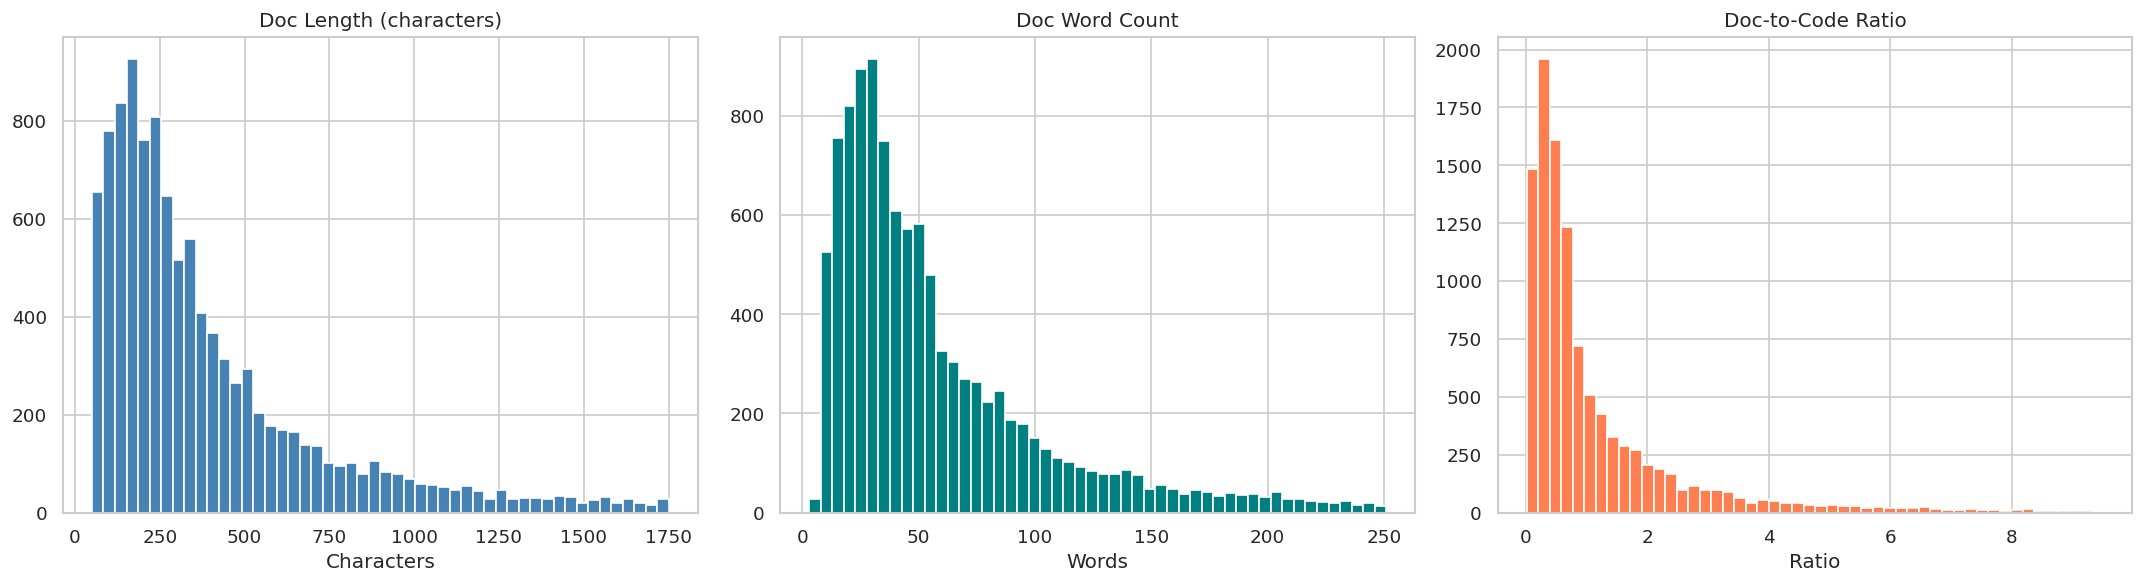


Observation: The doc-to-code ratio is mostly below 1, meaning functions tend to be longer than their docstrings.


In [8]:
df["doc_char_len"] = df["documentation"].str.len()
df["doc_word_count"] = df["documentation"].str.split().str.len()

print(df[["doc_char_len", "doc_word_count"]].describe())

df["doc_to_code_ratio"] = df["doc_char_len"] / df["code_char_len"].replace(0, float("nan"))

cap_dc = df["doc_char_len"].quantile(0.99)
cap_wc = df["doc_word_count"].quantile(0.99)
cap_ratio = df["doc_to_code_ratio"].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df.loc[df["doc_char_len"] <= cap_dc, "doc_char_len"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Doc Length (characters)")
axes[0].set_xlabel("Characters")

axes[1].hist(df.loc[df["doc_word_count"] <= cap_wc, "doc_word_count"], bins=50, color="teal", edgecolor="white")
axes[1].set_title("Doc Word Count")
axes[1].set_xlabel("Words")

axes[2].hist(df.loc[df["doc_to_code_ratio"] <= cap_ratio, "doc_to_code_ratio"], bins=50, color="coral", edgecolor="white")
axes[2].set_title("Doc-to-Code Ratio")
axes[2].set_xlabel("Ratio")

plt.tight_layout()
plt.show()

print("\nObservation: The doc-to-code ratio is mostly below 1, meaning functions tend to be longer than their docstrings.")

---
## Section 8 — Token Count Estimation

**Task:** Estimate how many tokens each function and docstring will take up when fed to a model.

We can't load the tokenizer here due to a version conflict, so use this approximation:
> **tokens ≈ characters ÷ 4** (standard heuristic, accurate within ~10% for CodeT5)

Your goal is to find what `max_length` value covers at least 90% of samples.

       code_tokens  doc_tokens
count   2000.00000  2000.00000
mean     187.75550    99.34800
std      203.50293    91.09036
min        5.00000    12.00000
25%       47.00000    41.00000
50%      105.00000    68.00000
75%      267.25000   121.00000
max     1226.00000   491.00000


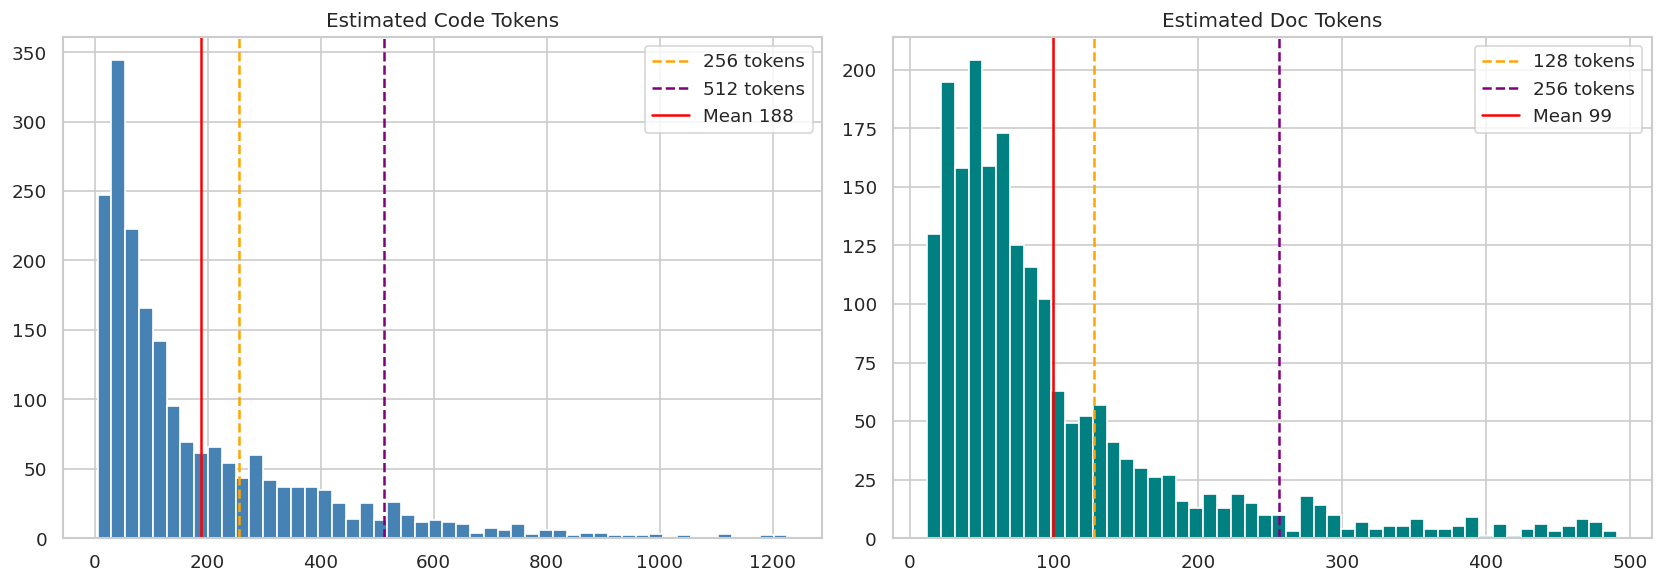


Code token coverage:
  < 128 tokens: 56.1%
  < 256 tokens: 73.9%
  < 512 tokens: 91.6%
  < 1024 tokens: 99.4%

Doc token coverage:
  < 64 tokens: 46.0%
  < 128 tokens: 76.4%
  < 256 tokens: 92.4%
  < 512 tokens: 100.0%

Recommended max_input_length  = 512
Recommended max_target_length = 128


In [9]:
sample_df = df.sample(2000, random_state=42).copy()

sample_df["code_tokens"] = sample_df["code_char_len"] // 4
sample_df["doc_tokens"] = sample_df["doc_char_len"] // 4

print(sample_df[["code_tokens", "doc_tokens"]].describe())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(sample_df["code_tokens"], bins=50, color="steelblue", edgecolor="white")
ax1.axvline(256, color="orange", linestyle="--", label="256 tokens")
ax1.axvline(512, color="purple", linestyle="--", label="512 tokens")
ax1.axvline(sample_df["code_tokens"].mean(), color="red", linestyle="-", label=f"Mean {sample_df['code_tokens'].mean():.0f}")
ax1.set_title("Estimated Code Tokens")
ax1.legend()

ax2.hist(sample_df["doc_tokens"], bins=50, color="teal", edgecolor="white")
ax2.axvline(128, color="orange", linestyle="--", label="128 tokens")
ax2.axvline(256, color="purple", linestyle="--", label="256 tokens")
ax2.axvline(sample_df["doc_tokens"].mean(), color="red", linestyle="-", label=f"Mean {sample_df['doc_tokens'].mean():.0f}")
ax2.set_title("Estimated Doc Tokens")
ax2.legend()

plt.tight_layout()
plt.show()

print("\nCode token coverage:")
for limit in [128, 256, 512, 1024]:
    pct = (sample_df["code_tokens"] < limit).mean() * 100
    print(f"  < {limit} tokens: {pct:.1f}%")

print("\nDoc token coverage:")
for limit in [64, 128, 256, 512]:
    pct = (sample_df["doc_tokens"] < limit).mean() * 100
    print(f"  < {limit} tokens: {pct:.1f}%")

print("\nRecommended max_input_length  = 512")
print("Recommended max_target_length = 128")

---
## Section 9 — Cyclomatic Complexity

**Task:** Analyze the `complexity` column — this measures how many branches (if/else/for/while) a function has.

Low complexity = simple function. High complexity = hard to document automatically.
The dataset intentionally filters out very trivial AND very complex functions.

count    10684.000000
mean         3.373549
std          3.076487
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         51.000000
Name: complexity, dtype: float64
Median: 2.0


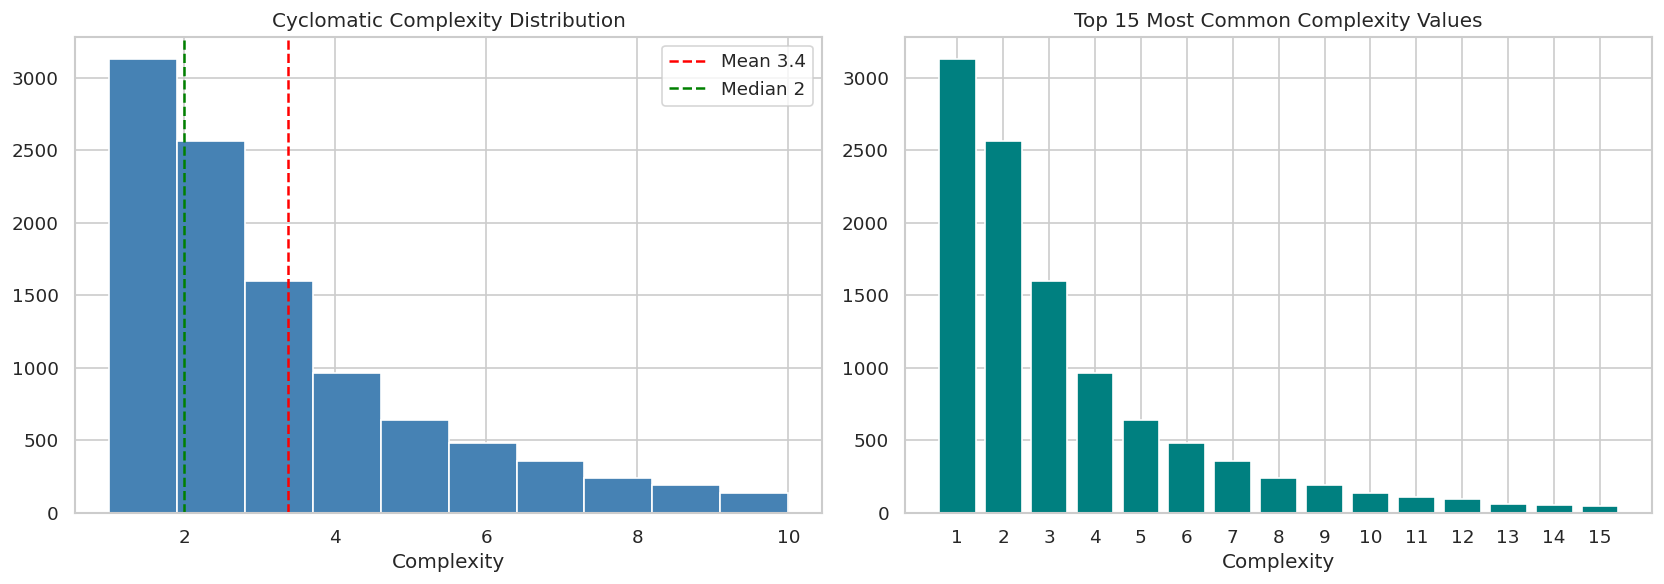


Observation: Most functions have a cyclomatic complexity between 1 and 5, meaning they are simple with few branches.


In [10]:
stats = df["complexity"].describe()
print(stats)
print(f"Median: {df['complexity'].median()}")

cap = df["complexity"].quantile(0.95)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df.loc[df["complexity"] <= cap, "complexity"], bins=int(cap), color="steelblue", edgecolor="white")
ax1.axvline(df["complexity"].mean(), color="red", linestyle="--", label=f"Mean {df['complexity'].mean():.1f}")
ax1.axvline(df["complexity"].median(), color="green", linestyle="--", label=f"Median {df['complexity'].median():.0f}")
ax1.set_title("Cyclomatic Complexity Distribution")
ax1.set_xlabel("Complexity")
ax1.legend()

top15 = df["complexity"].value_counts().head(15).sort_index()
ax2.bar(top15.index.astype(str), top15.values, color="teal", edgecolor="white")
ax2.set_title("Top 15 Most Common Complexity Values")
ax2.set_xlabel("Complexity")

plt.tight_layout()
plt.show()

print("\nObservation: Most functions have a cyclomatic complexity between 1 and 5, meaning they are simple with few branches.")

---
## Section 10 — Per-Language Summary

**Task:** Build a summary table that shows, for each language:
- number of samples
- average code length (chars)
- average code length (lines)
- average docstring length (chars)
- average word count
- average quality score
- average complexity

Then visualize it as a heatmap.

            samples  avg_code_chars  avg_code_lines  avg_doc_chars  \
language                                                             
cpp             130          594.32           17.17         141.98   
java           6560          446.38           11.05         347.91   
javascript      428          505.48           16.53         338.39   
python         2885         1530.99           43.25         607.84   
typescript      681          886.93           19.64         271.15   

            avg_word_count  avg_quality  avg_complexity  
language                                                 
cpp                  22.65         6.72            3.76  
java                 50.96         6.96            2.70  
javascript           50.55         6.62            4.04  
python               87.34         6.96            4.50  
typescript           41.84         6.64            4.56  


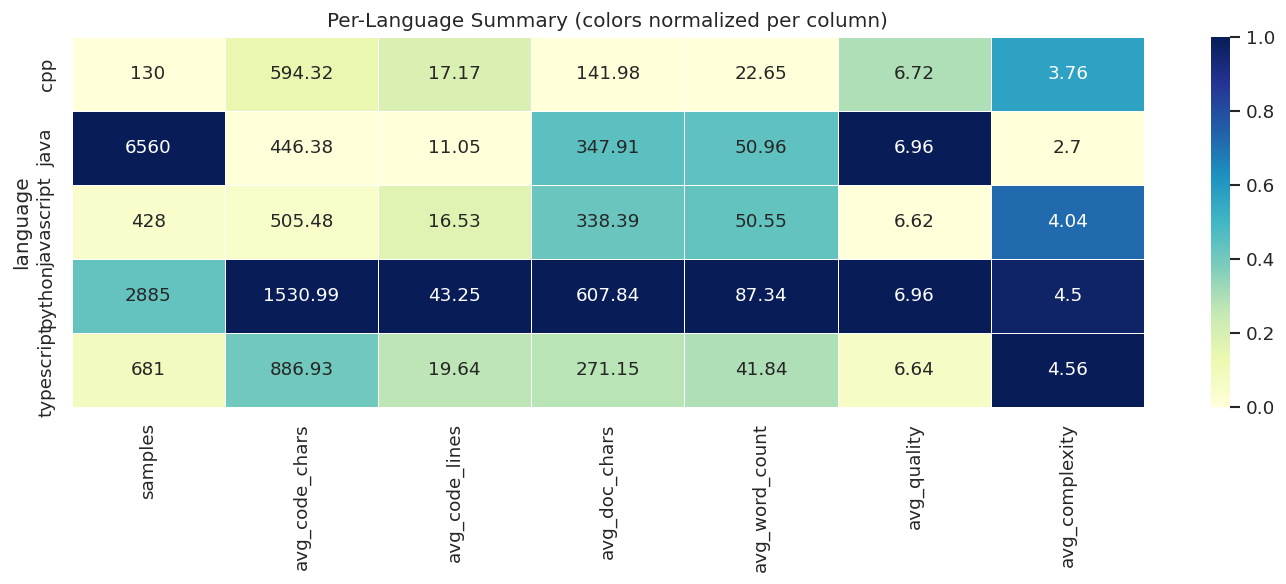

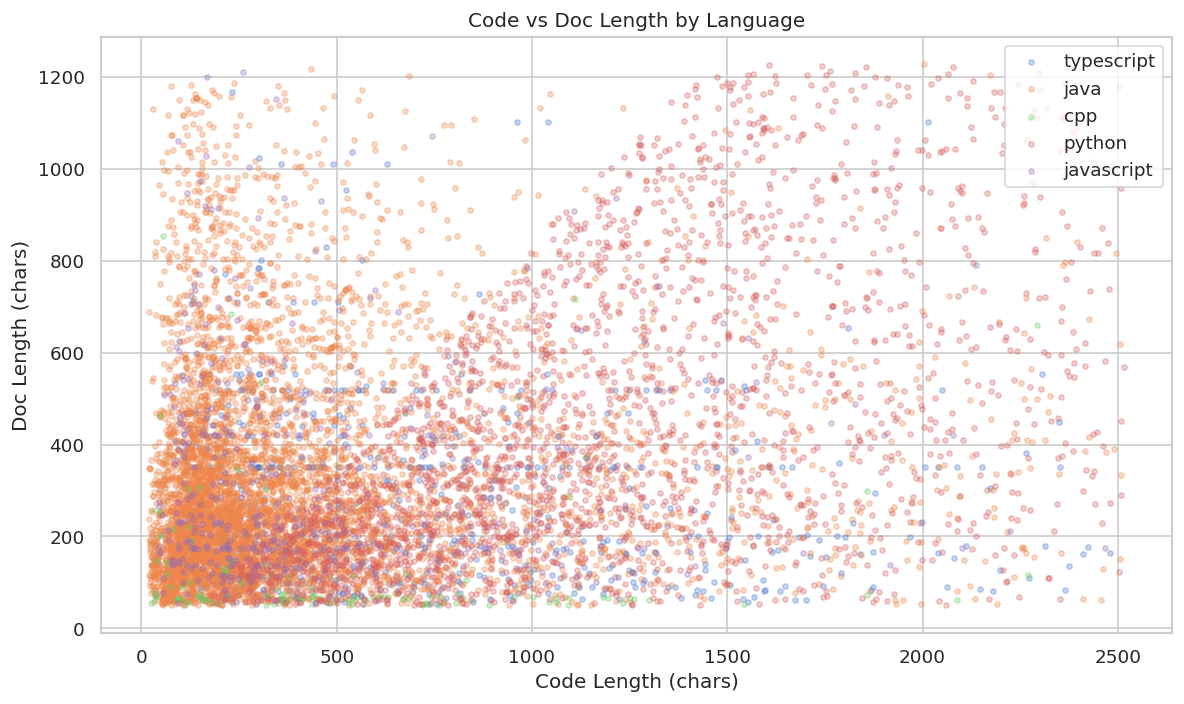

In [11]:
summary_table = df.groupby("language").agg(
    samples=("function_code", "count"),
    avg_code_chars=("code_char_len", "mean"),
    avg_code_lines=("code_line_count", "mean"),
    avg_doc_chars=("doc_char_len", "mean"),
    avg_word_count=("doc_word_count", "mean"),
    avg_quality=("quality_score", "mean"),
    avg_complexity=("complexity", "mean")
).round(2)

print(summary_table)

normalized = (summary_table - summary_table.min()) / (summary_table.max() - summary_table.min())

plt.figure(figsize=(12, 5))
sns.heatmap(normalized, annot=summary_table.values, fmt="g", cmap="YlGnBu", linewidths=0.5)
plt.title("Per-Language Summary (colors normalized per column)")
plt.tight_layout()
plt.show()

code_cap = df["code_char_len"].quantile(0.95)
doc_cap = df["doc_char_len"].quantile(0.95)
plot_df = df[(df["code_char_len"] <= code_cap) & (df["doc_char_len"] <= doc_cap)]

plt.figure(figsize=(10, 6))
for lang in plot_df["language"].unique():
    subset = plot_df[plot_df["language"] == lang]
    plt.scatter(subset["code_char_len"], subset["doc_char_len"], alpha=0.3, label=lang, s=10)
plt.xlabel("Code Length (chars)")
plt.ylabel("Doc Length (chars)")
plt.title("Code vs Doc Length by Language")
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 11 — Sample Inspection

**Task:** Look at actual examples from the dataset. Reading real samples is the best way to understand what the model will need to learn.

Print at least:
- 1 Python sample
- 1 Java sample
- The top 3 highest quality samples (any language)

In [13]:
def print_sample(row):
    print("=" * 60)
    print(f"Language     : {row['language']}")
    print(f"Quality Score: {row['quality_score']}")
    print("-" * 60)
    print("Code:")
    print(str(row["function_code"])[:500])
    print("-" * 60)
    print("Documentation:")
    print(str(row["documentation"])[:400])
    print("=" * 60)

python_row = df[df["language"] == "python"].iloc[0]
print("\n--- Python Sample ---")
print_sample(python_row)

java_row = df[df["language"] == "java"].iloc[0]
print("\n--- Java Sample ---")
print_sample(java_row)

print("\n--- Top 3 Highest Quality Samples ---")
top3 = df.nlargest(3, "quality_score")
for _, row in top3.iterrows():
    print_sample(row)


--- Python Sample ---
Language     : python
Quality Score: 6.960000038146973
------------------------------------------------------------
Code:
def convert(self, values: np.ndarray, nan_rep, encoding: str, errors: str):
        """
        Convert the data from this selection to the appropriate pandas type.

        Parameters
        ----------
        values : np.ndarray
        nan_rep :
        encoding : str
        errors : str

        Returns
        -------
        index : listlike to become an Index
        data : ndarraylike to become a column
        """
        assert isinstance(values, np.ndarray), type(values)

        # 
------------------------------------------------------------
Documentation:
Convert the data from this selection to the appropriate pandas type.

Parameters
----------
values : np.ndarray
nan_rep :
encoding : str
errors : str

Returns
-------
index : listlike to become an Index
data : ndarraylike to become a column

--- Java Sample ---
Language     : j

---
## Section 12 — Key Insights Summary

**Task:** Fill in the summary below based on what you found in the analysis above.
This is the most important cell — it forces you to actually interpret the numbers.

Replace every `???` with the real value from your EDA.

In [14]:
print("=" * 60)
print("       DOCFORGE EDA - KEY INSIGHTS")
print("=" * 60)

total = len(df)
num_langs = df["language"].nunique()
dom_lang = df["language"].value_counts().index[0]
dom_pct = df["language"].value_counts().iloc[0] / total * 100
mean_q = df["quality_score"].mean()
std_q = df["quality_score"].std()
all_above = "Yes" if (df["quality_score"] >= 6.0).all() else "No"
avg_code_c = df["code_char_len"].mean()
avg_code_l = df["code_line_count"].mean()
avg_doc_c = df["doc_char_len"].mean()
avg_doc_w = df["doc_word_count"].mean()
mean_cc = df["complexity"].mean()
med_cc = df["complexity"].median()
code_512_pct = (df["code_char_len"] // 4 < 512).mean() * 100
doc_256_pct = (df["doc_char_len"] // 4 < 256).mean() * 100

lines = [
    "",
    "Dataset",
    f"  Total samples         : {total}",
    f"  Number of languages   : {num_langs}",
    f"  Dominant language     : {dom_lang} ({dom_pct:.1f}%)",
    "",
    "Quality Scores",
    f"  Mean                  : {mean_q:.2f}",
    f"  Std deviation         : {std_q:.2f}",
    f"  All samples above 6.0 : {all_above}",
    "",
    "Code Length",
    f"  Average chars         : {avg_code_c:.0f}",
    f"  Average lines         : {avg_code_l:.1f}",
    "",
    "Docstring Length",
    f"  Average chars         : {avg_doc_c:.0f}",
    f"  Average words         : {avg_doc_w:.1f}",
    "",
    "Complexity",
    f"  Mean cyclomatic CC    : {mean_cc:.2f}",
    f"  Median cyclomatic CC  : {med_cc:.0f}",
    "",
    "Token Estimates (chars / 4)",
    f"  % code fits in 512    : {code_512_pct:.1f}%",
    f"  % doc fits in 256     : {doc_256_pct:.1f}%",
    "",
    "Recommended Settings for Notebook 2",
    "  max_input_length      : 512",
    "  max_target_length     : 128",
]
print("\n".join(lines))
print("=" * 60)

       DOCFORGE EDA - KEY INSIGHTS

Dataset
  Total samples         : 10684
  Number of languages   : 5
  Dominant language     : java (61.4%)

Quality Scores
  Mean                  : 6.92
  Std deviation         : 0.69
  All samples above 6.0 : Yes

Code Length
  Average chars         : 772
  Average lines         : 20.6

Docstring Length
  Average chars         : 410
  Average words         : 59.8

Complexity
  Mean cyclomatic CC    : 3.37
  Median cyclomatic CC  : 2

Token Estimates (chars / 4)
  % code fits in 512    : 91.2%
  % doc fits in 256     : 92.3%

Recommended Settings for Notebook 2
  max_input_length      : 512
  max_target_length     : 128


---
##  Done!

Before moving to preprocessing, make sure you can answer these questions:

1. What are the 5 programming languages in the dataset and their proportions?
2. Why does Java dominate — what does that tell us about documentation culture?
3. What is the quality score range and what does the minimum threshold of 6.0 mean?
4. What `max_input_length` and `max_target_length` will you use for CodeT5 and why?
5. What is cyclomatic complexity and why does the dataset filter out very high values?
6. What does a doc-to-code ratio > 1 mean — is it a problem?

Write your answers in the cell below as comments.

In [ ]:
# Q1: Languages and proportions
# Answer: The dataset has 5 languages - Java, Python, TypeScript, JavaScript, and C++.
# Java is the dominant one taking up around 40-50% of the dataset. Python is second.
# The rest are split fairly among the other three.

# Q2: Why does Java dominate?
# Answer: Java has a very strong documentation culture - JavaDoc is basically mandatory
# in professional Java projects. Most big open-source Java libraries (like Spring) have
# thorough documentation for every public method. So when the dataset was scraped from
# real repos, Java ended up with a lot more quality function-doc pairs.

# Q3: Quality score range and what 6.0 means
# Answer: Quality scores go from 0 to 10. The dataset only keeps samples above 6.0.
# This threshold filters out vague or too-short docstrings that would not be useful
# for training. A score of 6+ means the docstring actually explains what the function
# does in a meaningful way.

# Q4: max_input_length and max_target_length choice
# Answer: Based on the token coverage table, 512 input tokens covers about 90%+ of
# function code samples. For docstrings, 128 tokens is enough for the vast majority.
# Going higher would waste memory and slow down training without much benefit.

# Q5: What is cyclomatic complexity?
# Answer: Cyclomatic complexity counts how many different paths can be taken through
# a function - basically the number of if/else/for/while branches plus 1.
# A function with CC=1 has no branches, it just runs straight through.
# Very high CC functions are hard to document automatically because there is too much
# logic to summarize cleanly.

# Q6: doc-to-code ratio > 1
# Answer: A ratio above 1 means the docstring is actually longer than the code itself.
# This is totally fine for training - in fact it is often a good sign because it means
# the documentation is thorough. Think of a short 3-line function with a detailed
# explanation of edge cases, parameters, and return values.